# CNN for Trading - Part 3: Training and Evaluating a CNN

To exploit the grid-like structure of time-series data, we can use CNN architectures for univariate and multivariate time series. In the latter case, we consider different time series as channels, similar to the different color signals.

An alternative approach converts a time series of alpha factors into a two-dimensional format to leverage the ability of CNNs to detect local patterns. [Sezer and Ozbayoglu (2018)](https://www.researchgate.net/publication/324802031_Algorithmic_Financial_Trading_with_Deep_Convolutional_Neural_Networks_Time_Series_to_Image_Conversion_Approach) propose CNN-TA, which computes 15 technical indicators for different intervals and uses hierarchical clustering (see Chapter 13, Data-Driven Risk Factors and Asset Allocation with Unsupervised Learning) to locate indicators that behave similarly close to each other in a two-dimensional grid.

The authors train a CNN similar to the CIFAR-10 example we used earlier to predict whether to buy, hold, or sell an asset on a given day. They compare the CNN performance to "buy-and-hold" and other models and find that it outperforms all alternatives using daily price series for Dow 30 stocks and the nine most-traded ETFs over the 2007-2017 time period.

The section on *CNN for Trading* consists of three notebooks that experiment with this approach using daily US equity price data. They demonstrate 
1. How to compute relevant financial features
2. How to convert a similar set of indicators into image format and cluster them by similarity
3. How to train a CNN to predict daily returns and evaluate a simple long-short strategy based on the resulting signals.

## Creating and training a convolutional neural network

Now we are ready to design, train, and evaluate a CNN following the steps outlined in the
previous section.

## Imports

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [13]:
%matplotlib inline

from time import time
from pathlib import Path
import sys, os

import numpy as np
import pandas as pd

from sklearn.preprocessing import MinMaxScaler
from scipy.stats import spearmanr

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, Input

import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
gpu_devices = tf.config.experimental.list_physical_devices("GPU")
if gpu_devices:
    print("Using GPU")
    tf.config.experimental.set_memory_growth(gpu_devices[0], True)
else:
    print("Using CPU")

Using CPU


In [4]:
sys.path.append(os.path.dirname(os.getcwd()))
from utils import MultipleTimeSeriesCV, format_time

In [5]:
sns.set_style("whitegrid")
np.random.seed(42)

In [6]:
size = 15
lookahead = 1

In [7]:
results_path = Path("results", "cnn_for_trading")
if not results_path.exists():
    results_path.mkdir(parents=True)

## Load Model Data

In [8]:
with pd.HDFStore("data.h5") as store:
    features = store["img_data"]
    targets = store["targets"]

In [9]:
features.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 2378728 entries, ('A', Timestamp('2001-01-02 00:00:00')) to ('ZTS', Timestamp('2017-12-29 00:00:00'))
Columns: 225 entries, 01_CMO to 11_WMA
dtypes: float32(195), float64(30)
memory usage: 2.3+ GB


In [10]:
targets.info()

<class 'pandas.core.frame.DataFrame'>
MultiIndex: 2378728 entries, ('A', Timestamp('2001-01-02 00:00:00')) to ('ZTS', Timestamp('2017-12-29 00:00:00'))
Data columns (total 4 columns):
 #   Column      Dtype  
---  ------      -----  
 0   r01_fwd     float64
 1   r01dec_fwd  float64
 2   r05_fwd     float64
 3   r05dec_fwd  float64
dtypes: float64(4)
memory usage: 81.8+ MB


In [11]:
outcome = f"r{lookahead:02}_fwd"
features = features.join(targets[[outcome]]).dropna()
target = features[outcome]
features = features.drop(outcome, axis=1)

## Convolutional Neural Network

We again closely follow the authors in creating a CNN with 2 convolutional layers with kernel size 3 and 16 and 32 filters, respectively, followed by a max pooling layer of size 2. 

We flatten the output of the last stack of filters and connect the resulting 1,568 outputs to a dense layer of size 32, applying 25 and 50 percent dropout probability to the incoming and outcoming connections to mitigate overfitting.

### Model Architecture

In [14]:
def make_model(
    filter1=16, act1="relu", filter2=32, act2="relu", do1=0.25, do2=0.5, dense=32
):
    input_shape = (size, size, 1)
    cnn = Sequential(
        [
            Input(shape=input_shape),
            Conv2D(
                filters=filter1,
                kernel_size=3,
                padding="same",
                activation=act1,
                name="CONV1",
            ),
            Conv2D(
                filters=filter2,
                kernel_size=3,
                padding="same",
                activation=act2,
                name="CONV2",
            ),
            MaxPooling2D(pool_size=2, name="POOL2"),
            Dropout(do1, name="DROP1"),
            Flatten(name="FLAT1"),
            Dense(dense, activation="relu", name="FC1"),
            Dropout(do2, name="DROP2"),
            Dense(1, activation="linear", name="FC2"),
        ]
    )
    cnn.compile(
        loss="mse",
        optimizer=tf.keras.optimizers.SGD(
            learning_rate=0.01, momentum=0.9, nesterov=False, name="SGD"
        ),
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse")],
    )
    return cnn

In [15]:
cnn = make_model()
cnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ CONV1 (Conv2D)                  │ (None, 15, 15, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ CONV2 (Conv2D)                  │ (None, 15, 15, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ POOL2 (MaxPooling2D)            │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ DROP1 (Dropout)                 │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FLAT1 (Flatten)                 │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC1 (Dense)                     │ (None, 32)             │        50,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ DROP2 (Dropout)                 │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ FC2 (Dense)                     │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,041 (215.00 KB)

 Trainable params: 55,041 (215.00 KB)

 Non-trainable params: 0 (0.00 B)

### Train the Model

We cross-validate the model with the MutipleTimeSeriesCV train and validation set index generator introduced in Chapter 7, Linear Models – From Risk Factors to Return Forecasts. We provide 5 years of trading days during the training period in batches of 64 random samples and validate using the subsequent 3 months, covering the years 2014-2017.

In [17]:
train_period_length = 5 * 12 * 21
test_period_length = 5 * 21
n_splits = 16

In [18]:
cv = MultipleTimeSeriesCV(
    n_splits=n_splits,
    train_period_length=train_period_length,
    test_period_length=test_period_length,
    lookahead=lookahead,
)

We scale the features to the range [-1, 1] and again use NumPy's .reshape() method to create the requisite format: 

In [20]:
def get_train_valid_data(X, y, train_idx, test_idx):
    x_train, y_train = X.iloc[train_idx, :], y.iloc[train_idx]
    x_val, y_val = X.iloc[test_idx, :], y.iloc[test_idx]
    scaler = MinMaxScaler(feature_range=(-1, 1))
    x_train = scaler.fit_transform(x_train)
    x_val = scaler.transform(x_val)
    return (
        x_train.reshape(-1, size, size, 1),
        y_train,
        x_val.reshape(-1, size, size, 1),
        y_val,
    )

In [21]:
batch_size = 64

In [22]:
checkpoint_path = results_path / f"lookahead_{lookahead:02d}"
if not checkpoint_path.exists():
    checkpoint_path.mkdir(parents=True, exist_ok=True)

Training and validation follow the process laid out in Chapter 17, Deep Learning for Trading, relying on checkpointing to store weights after each epoch and generate predictions for the best-performing iterations without the need for costly retraining.

In [24]:
start = time()
ic = []
for fold, (train_idx, test_idx) in enumerate(cv.split(features)):
    X_train, y_train, X_val, y_val = get_train_valid_data(
        features, target, train_idx, test_idx
    )
    preds = y_val.to_frame("actual")
    r = pd.DataFrame(index=y_val.index.unique(level="date")).sort_index()
    model = make_model(
        filter1=16, act1="relu", filter2=32, act2="relu", do1=0.25, do2=0.5, dense=32
    )
    best_mean = best_median = -np.inf
    for epoch in range(25):
        model.fit(
            X_train,
            y_train,
            batch_size=batch_size,
            validation_data=(X_val, y_val),
            epochs=epoch + 1,
            initial_epoch=epoch,
            verbose=0,
            shuffle=True,
        )
        model.save_weights((checkpoint_path / f"ckpt_{fold}_{epoch}.weights.h5").as_posix())
        preds[epoch] = model.predict(X_val).squeeze()
        r[epoch] = (
            preds.groupby(level="date")
            .apply(lambda x: spearmanr(x.actual, x[epoch])[0])
            .to_frame(epoch)
        )
        print(
            f"{format_time(time() - start)} | {fold + 1:02d} | {epoch + 1:02d} | {r[epoch].mean():7.4f} | {r[epoch].median():7.4f}"
        )
    ic.append(r.assign(fold=fold))
ic = pd.concat(ic)
ic.to_csv(checkpoint_path / "ic.csv")

1476/1476 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
00:00:46 | 01 | 01 |  0.0005 |  0.0019
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
00:01:30 | 01 | 02 | -0.0020 | -0.0085
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
00:02:24 | 01 | 03 |  0.0040 | -0.0016
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
00:03:10 | 01 | 04 | -0.0009 | -0.0055
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
00:03:56 | 01 | 05 |  0.0051 |  0.0042
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
00:04:43 | 01 | 06 |  0.0027 |  0.0042
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
00:05:29 | 01 | 07 |  0.0038 |  0.0047
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
00:06:12 | 01 | 08 |  0.0045 |  0.0085
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
00:06:56 | 01 | 09 |  0.0059 |  0.0082
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
00:07:41 | 01 | 10 |  0.0054 |  0.0088
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
00:08:29 | 01 | 11 |  0.0069 |  0.0088
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
00:09:16 | 01 | 12 |  0.0061 |  0.0101
1476/1476 ━━━━━━

### Evaluate results

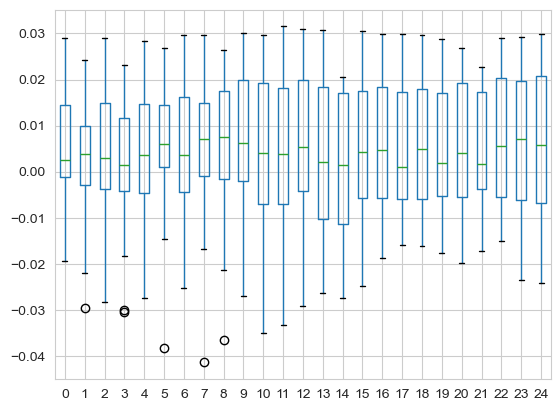

In [25]:
ic.groupby("fold").mean().boxplot();

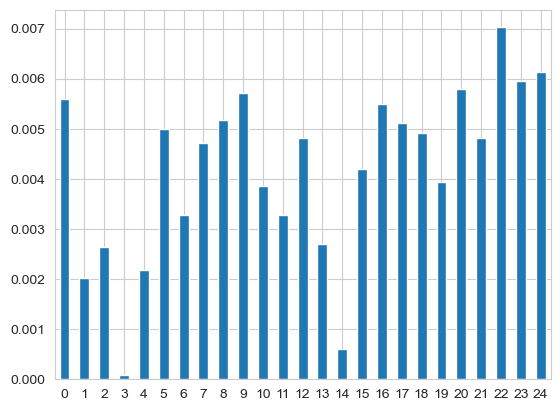

In [26]:
ic.groupby("fold").mean().mean().sort_index().plot.bar(rot=0);

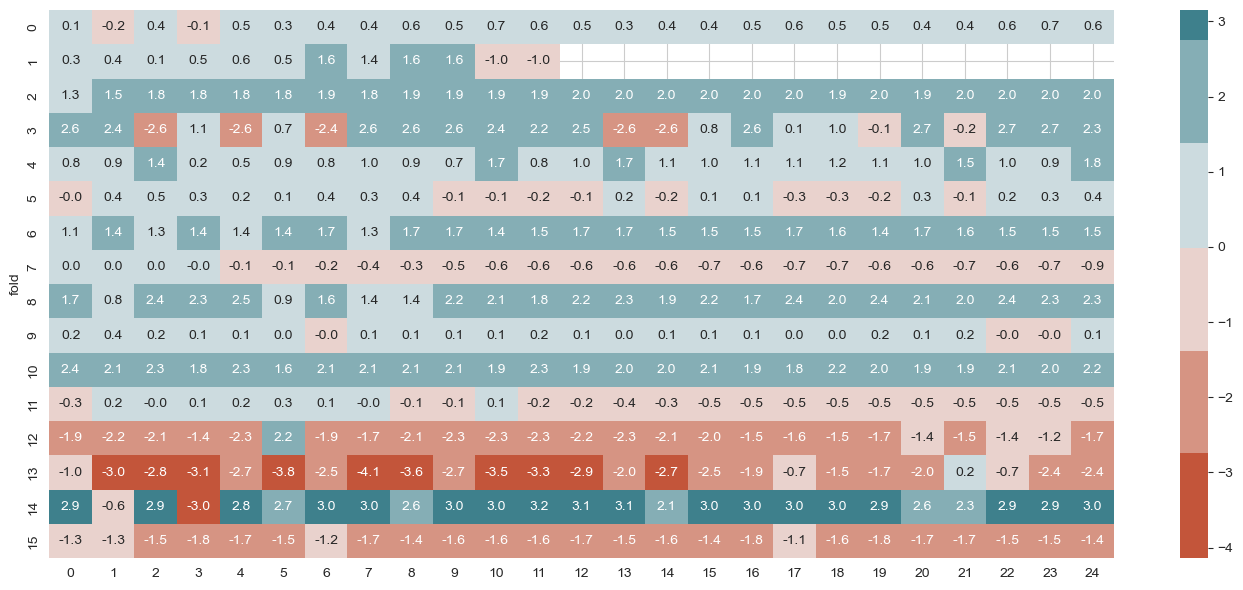

In [27]:
cmap = sns.diverging_palette(h_neg=20, h_pos=210)
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    ic.groupby("fold").mean().mul(100),
    ax=ax,
    center=0,
    cmap=cmap,
    annot=True,
    fmt=".1f",
)
fig.tight_layout()

## Make Predictions

To evaluate the model's predictive accuracy, we compute the daily information coefficient (IC) for the validation set like so:


In [30]:
def generate_predictions(epoch):
    predictions = []
    for fold, (train_idx, test_idx) in enumerate(cv.split(features)):
        X_train, y_train, X_val, y_val = get_train_valid_data(
            features, target, train_idx, test_idx
        )
        model = make_model(
            filter1=16,
            act1="relu",
            filter2=32,
            act2="relu",
            do1=0.25,
            do2=0.5,
            dense=32,
        )
        model.load_weights(
            (checkpoint_path / f"ckpt_{fold}_{epoch}.weights.h5").as_posix()
        )
        predictions.append(pd.Series(model.predict(X_val).squeeze(), index=y_val.index))
    return pd.concat(predictions)

In [31]:
preds = {}
for i, epoch in enumerate(ic.drop("fold", axis=1).mean().nlargest(5).index):
    preds[i] = generate_predictions(epoch)

1476/1476 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1621/1621 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1655/1655 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1739/1739 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1803/1803 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1823/1823 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1869/1869 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1858/1858 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1874/1874 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1842/1842 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1844/1844 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1850/1850 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1476/1476 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1532/1532 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1594/1594 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1621/1621 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1655/1655 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1712/1712 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1739/1739 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
1803/1803 ━

In [33]:
with pd.HDFStore(results_path / "predictions.h5") as store:
    store.put("predictions", pd.DataFrame(preds).sort_index())